In [ ]:
# ── Imports & paths ────────────────────────────────────────────────────────
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from collections import Counter
from wordcloud import WordCloud

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"]     = 120
sns.set_theme(style="darkgrid", palette="muted")

# ── Paths ──────────────────────────────────────────────────────────────────
REPO_ROOT  = Path().resolve().parents[1]
CLEAN_DIR  = REPO_ROOT / "Data" / "Clean"
INPUT_PATH = CLEAN_DIR / "cleaned_non_western_fiction.json"
EDA_DIR    = REPO_ROOT / "Reports" / "EDA"
EDA_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Setup complete")
print(f"   Input: {'✅' if INPUT_PATH.exists() else '❌'} {INPUT_PATH.name}")
print(f"   Charts saved to: {EDA_DIR}")

✅ Setup complete
   Input: ✅ cleaned_non_western_fantasy.json
   Charts saved to: C:\Users\Ready2Use\Documents\my-folder\Ironhack-week10\Book-recommendations\Reports\EDA


In [4]:
# ── Load data ──────────────────────────────────────────────────────────────
with open(INPUT_PATH, encoding="utf-8") as f:
    books = json.load(f)

df = pd.DataFrame(books)

# Fix data types
df["first_publish_year"] = pd.to_numeric(df["first_publish_year"], errors="coerce")
df["sg_rating"]          = pd.to_numeric(df["sg_rating"], errors="coerce")

# Add missing columns with defaults
if "tag_count" not in df.columns:
    df["tag_count"] = 0
if "cover_url" not in df.columns:
    df["cover_url"] = ""

# Add helper columns
df["has_description"] = df["description"].str.len() > 20
df["has_author"]      = df["author_name"].apply(lambda x: len(x) > 0 if isinstance(x, list) else bool(x))
df["has_cover"]       = df["cover_url"].str.len() > 0
df["desc_length"]     = df["description"].str.len()
df["num_subjects"]    = df["subject"].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"✅ Loaded {len(df):,} books")
print(f"\n── Quick overview ────────────────────────────────────────────────")
print(f"   Has description:  {df['has_description'].sum():,} ({df['has_description'].mean()*100:.1f}%)")
print(f"   Has author:       {df['has_author'].sum():,} ({df['has_author'].mean()*100:.1f}%)")
print(f"   Has cover:        {df['has_cover'].sum():,} ({df['has_cover'].mean()*100:.1f}%)")
print(f"   Has SG rating:    {df['sg_rating'].notna().sum():,} ({df['sg_rating'].notna().mean()*100:.1f}%)")
print(f"   Has publish year: {df['first_publish_year'].notna().sum():,} ({df['first_publish_year'].notna().mean()*100:.1f}%)")

✅ Loaded 7,506 books

── Quick overview ────────────────────────────────────────────────
   Has description:  1,316 (17.5%)
   Has author:       1,504 (20.0%)
   Has cover:        0 (0.0%)
   Has SG rating:    472 (6.3%)
   Has publish year: 1,514 (20.2%)


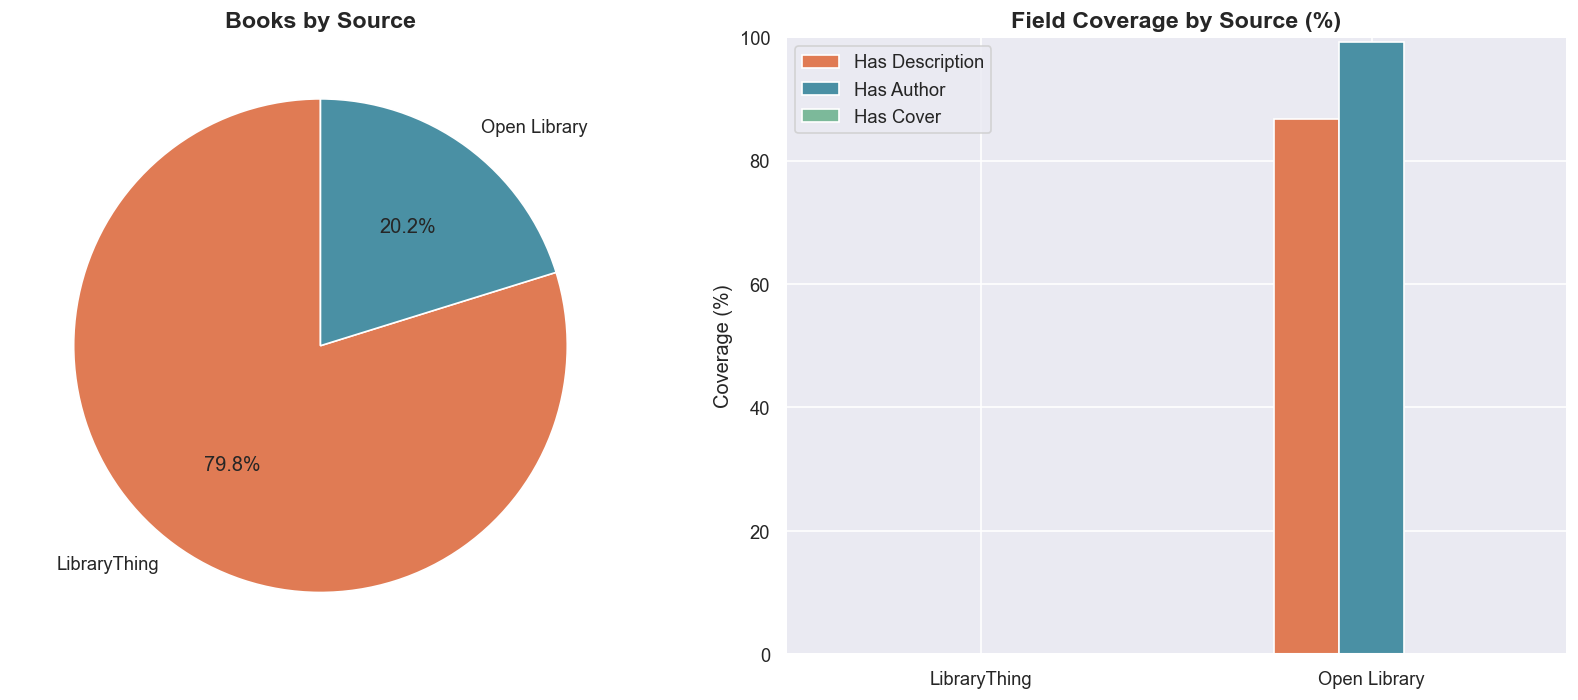

✅ Plot saved


In [5]:
# ── Plot 1: Source breakdown ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
source_counts = df["source"].value_counts()
axes[0].pie(
    source_counts.values,
    labels=["LibraryThing", "Open Library"],
    autopct="%1.1f%%",
    colors=["#E07B54", "#4A90A4"],
    startangle=90,
)
axes[0].set_title("Books by Source", fontsize=14, fontweight="bold")

# Bar chart of field coverage by source
coverage = df.groupby("source")[["has_description", "has_author", "has_cover"]].mean() * 100
coverage.plot(kind="bar", ax=axes[1], color=["#E07B54", "#4A90A4", "#7CB99A"])
axes[1].set_title("Field Coverage by Source (%)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Coverage (%)")
axes[1].set_xticklabels(["LibraryThing", "Open Library"], rotation=0)
axes[1].legend(["Has Description", "Has Author", "Has Cover"])
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(EDA_DIR / "01_source_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved")

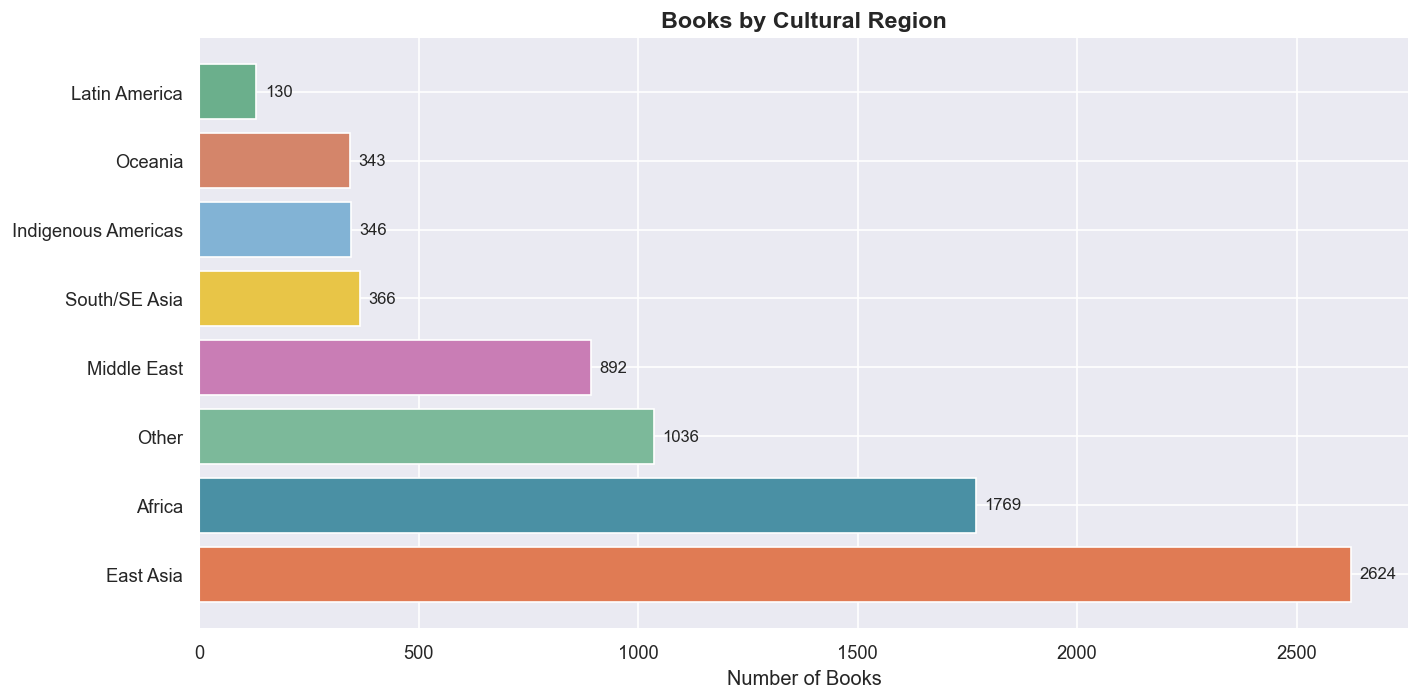

✅ Plot saved


In [6]:
# ── Plot 2: Cultural region breakdown ─────────────────────────────────────
REGION_MAP = {
    "Africa":           ["Afrofuturism", "Africanfuturism", "Africanjujuism",
                         "Yoruba", "Igbo", "Akan", "Zulu", "Xhosa", "Kikuyu",
                         "Wolof", "Hausa", "Orisha", "Juju", "Obeah", "Vodou",
                         "Anansi", "Nyame", "Griot"],
    "East Asia":        ["Wuxia", "Xianxia", "Xuanhuan", "Yokai", "Kami",
                         "Oni", "Tengu", "Kitsune", "Tanuki", "Shinto",
                         "Gumiho", "Dokkaebi", "Mudang"],
    "South/SE Asia":    ["Rakshasa", "Naga", "Apsara", "Deva", "Asura",
                         "Aswang", "Diwata", "Babaylan", "Anito",
                         "Manananggal", "Penanggal", "Pontianak", "Hantu"],
    "Middle East":      ["Djinn", "Ifrit", "Marid", "Ghoul", "Peri",
                         "Simurgh", "Zoroastrian"],
    "Latin America":    ["Quetzalcoatl", "Tlaloc", "Xibalba", "Nahua",
                         "Curandera", "Brujeria", "Santeria", "Candomble",
                         "Nagual", "Orixas", "Umbanda"],
    "Indigenous Americas": ["Anishinaabe", "Ojibwe", "Cree", "Métis",
                            "Haudenosaunee", "Wampanoag", "Pueblo", "Diné",
                            "Skinwalker", "Wendigo", "Thunderbird"],
    "Oceania":          ["Dreamtime", "Songlines", "Bunyip", "Tangaroa",
                         "Maui", "Papatuanuku", "Tapu", "Mana", "Atua"],
}

def get_region(source_tag):
    for region, tags in REGION_MAP.items():
        if source_tag in tags:
            return region
    return "Other"

df["region"] = df["source_tag"].apply(get_region)
region_counts = df["region"].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(region_counts.index, region_counts.values,
               color=["#E07B54", "#4A90A4", "#7CB99A", "#C97DB5",
                      "#E8C547", "#82B3D5", "#D4856A", "#6BAF8C"])
ax.set_title("Books by Cultural Region", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Books")

for bar, val in zip(bars, region_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=10)

plt.tight_layout()
plt.savefig(EDA_DIR / "02_cultural_regions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved")

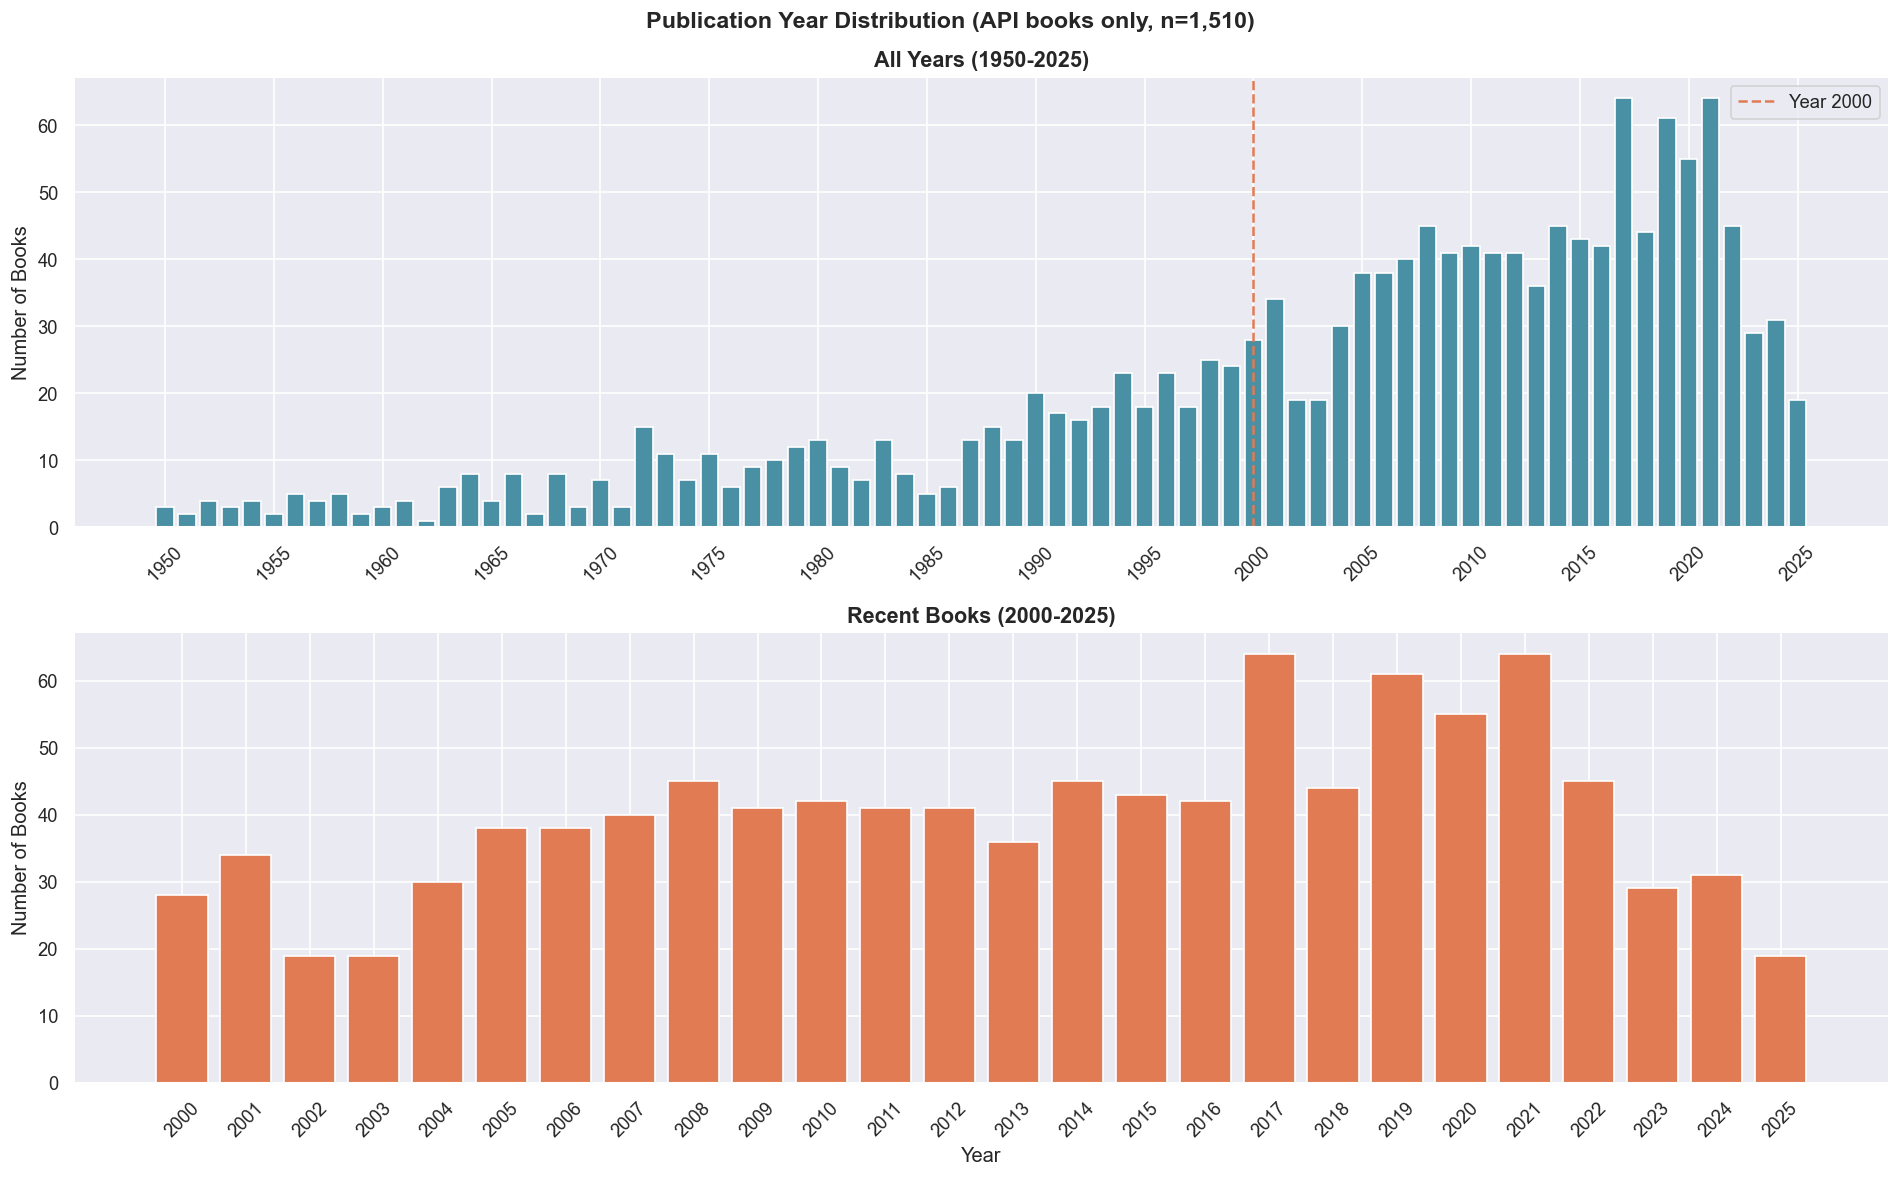

✅ Plot saved


In [10]:
# ── Plot 3: Publication year — one bar per year ────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

year_data = df["first_publish_year"].dropna()
year_data = year_data[(year_data >= 1950) & (year_data <= 2025)]
year_counts = year_data.value_counts().sort_index()

# Top — full range
axes[0].bar(year_counts.index, year_counts.values, color="#4A90A4", width=0.8)
axes[0].set_title("All Years (1950-2025)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Books")
axes[0].axvline(x=2000, color="#E07B54", linestyle="--", linewidth=1.5, label="Year 2000")
axes[0].set_xticks(range(1950, 2026, 5))
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# Bottom — post 2000 zoom
recent = year_counts[year_counts.index >= 2000]
axes[1].bar(recent.index, recent.values, color="#E07B54", width=0.8)
axes[1].set_title("Recent Books (2000-2025)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Books")
axes[1].set_xticks(range(2000, 2026, 1))
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle(f"Publication Year Distribution (API books only, n={len(year_data):,})",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(EDA_DIR / "03_publication_years.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved")

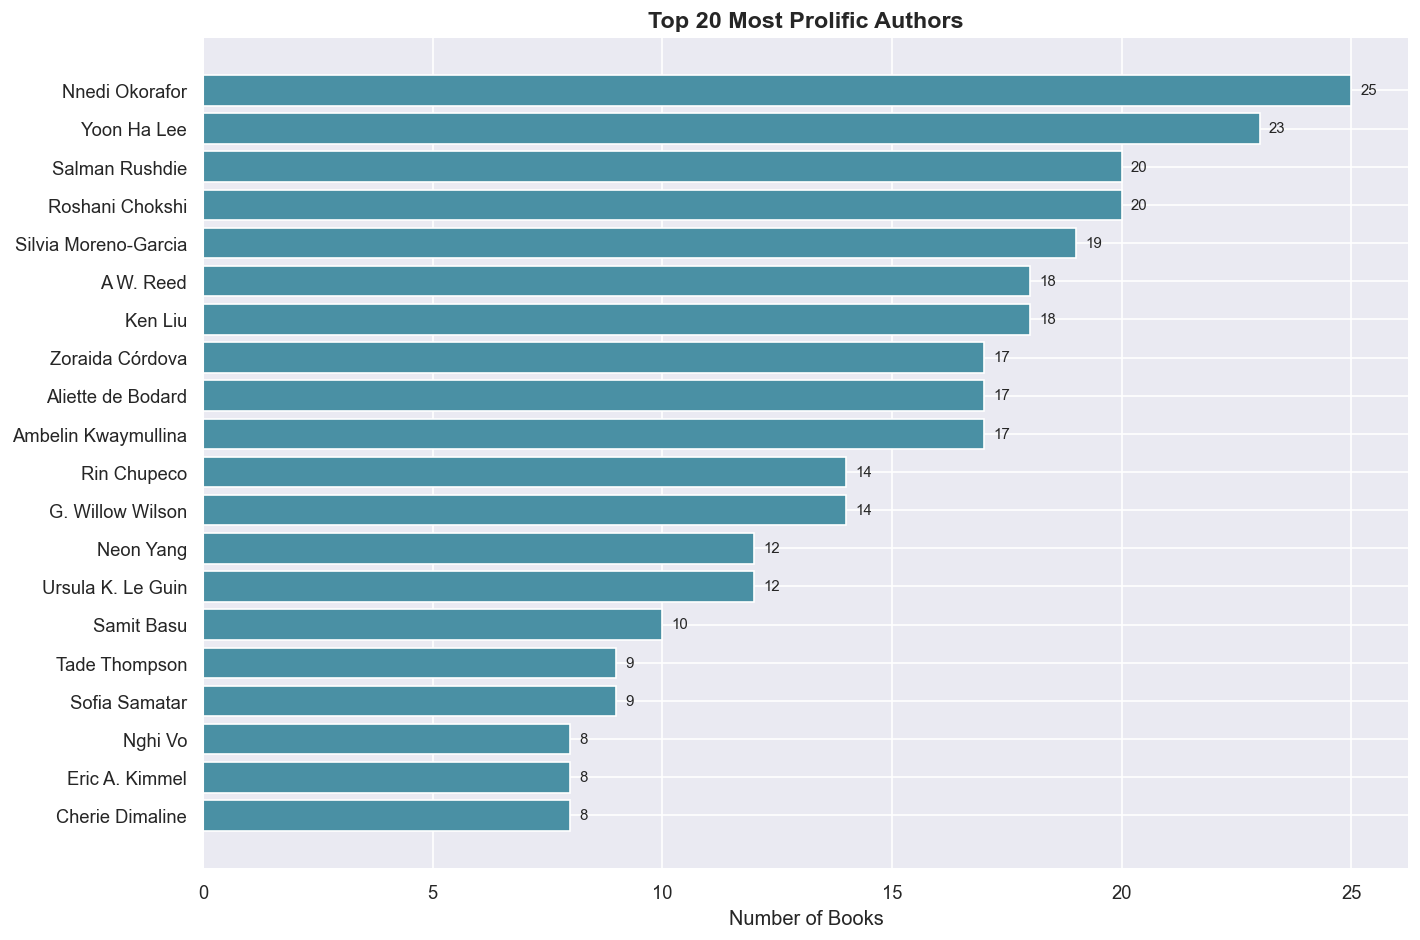

✅ Plot saved


In [11]:
# ── Plot 4: Top authors ────────────────────────────────────────────────────
from collections import Counter

all_authors = []
for authors in df["author_name"]:
    if isinstance(authors, list):
        all_authors.extend([a.strip() for a in authors if a.strip()])

author_counts = Counter(all_authors).most_common(20)
authors, counts = zip(*author_counts)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(list(reversed(authors)), list(reversed(counts)), color="#4A90A4")
ax.set_title("Top 20 Most Prolific Authors", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Books")

for bar, val in zip(bars, list(reversed(counts))):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / "04_top_authors.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved")

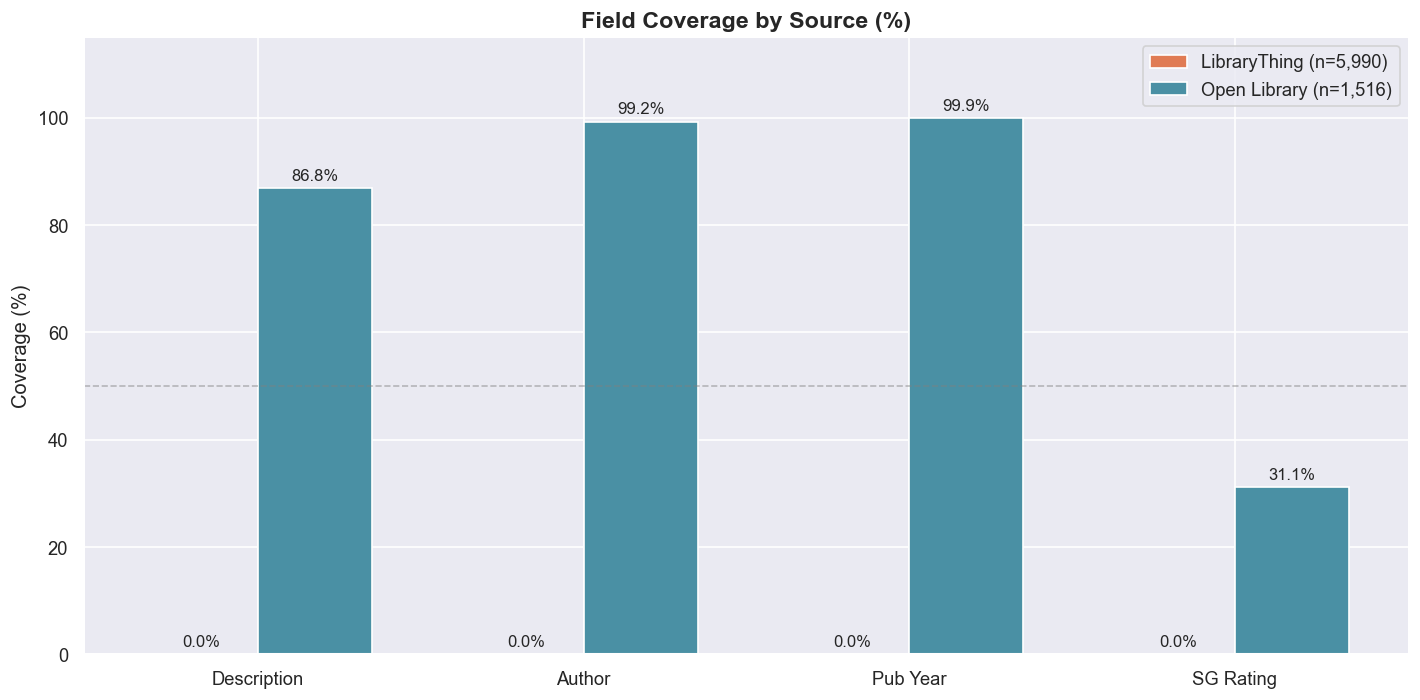

✅ Plot saved


In [13]:
# ── Plot 5: Coverage by source — cleaner ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

lt_books  = df[df["source"] == "librarything"]
ol_books  = df[df["source"] == "open_library"]

fields = ["Description", "Author", "Pub Year", "SG Rating"]
lt_coverage = [
    lt_books["has_description"].mean() * 100,
    lt_books["has_author"].mean() * 100,
    lt_books["first_publish_year"].notna().mean() * 100,
    (lt_books["sg_rating"].notna() & (lt_books["sg_rating"] > 0)).mean() * 100,
]
ol_coverage = [
    ol_books["has_description"].mean() * 100,
    ol_books["has_author"].mean() * 100,
    ol_books["first_publish_year"].notna().mean() * 100,
    (ol_books["sg_rating"].notna() & (ol_books["sg_rating"] > 0)).mean() * 100,
]

x = np.arange(len(fields))
width = 0.35

bars1 = ax.bar(x - width/2, lt_coverage, width, label=f"LibraryThing (n={len(lt_books):,})", color="#E07B54")
bars2 = ax.bar(x + width/2, ol_coverage, width, label=f"Open Library (n={len(ol_books):,})", color="#4A90A4")

ax.set_title("Field Coverage by Source (%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Coverage (%)")
ax.set_xticks(x)
ax.set_xticklabels(fields)
ax.set_ylim(0, 115)
ax.legend()
ax.axhline(y=50, color="gray", linestyle="--", linewidth=1, alpha=0.5)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(EDA_DIR / "05_coverage_by_source.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved")

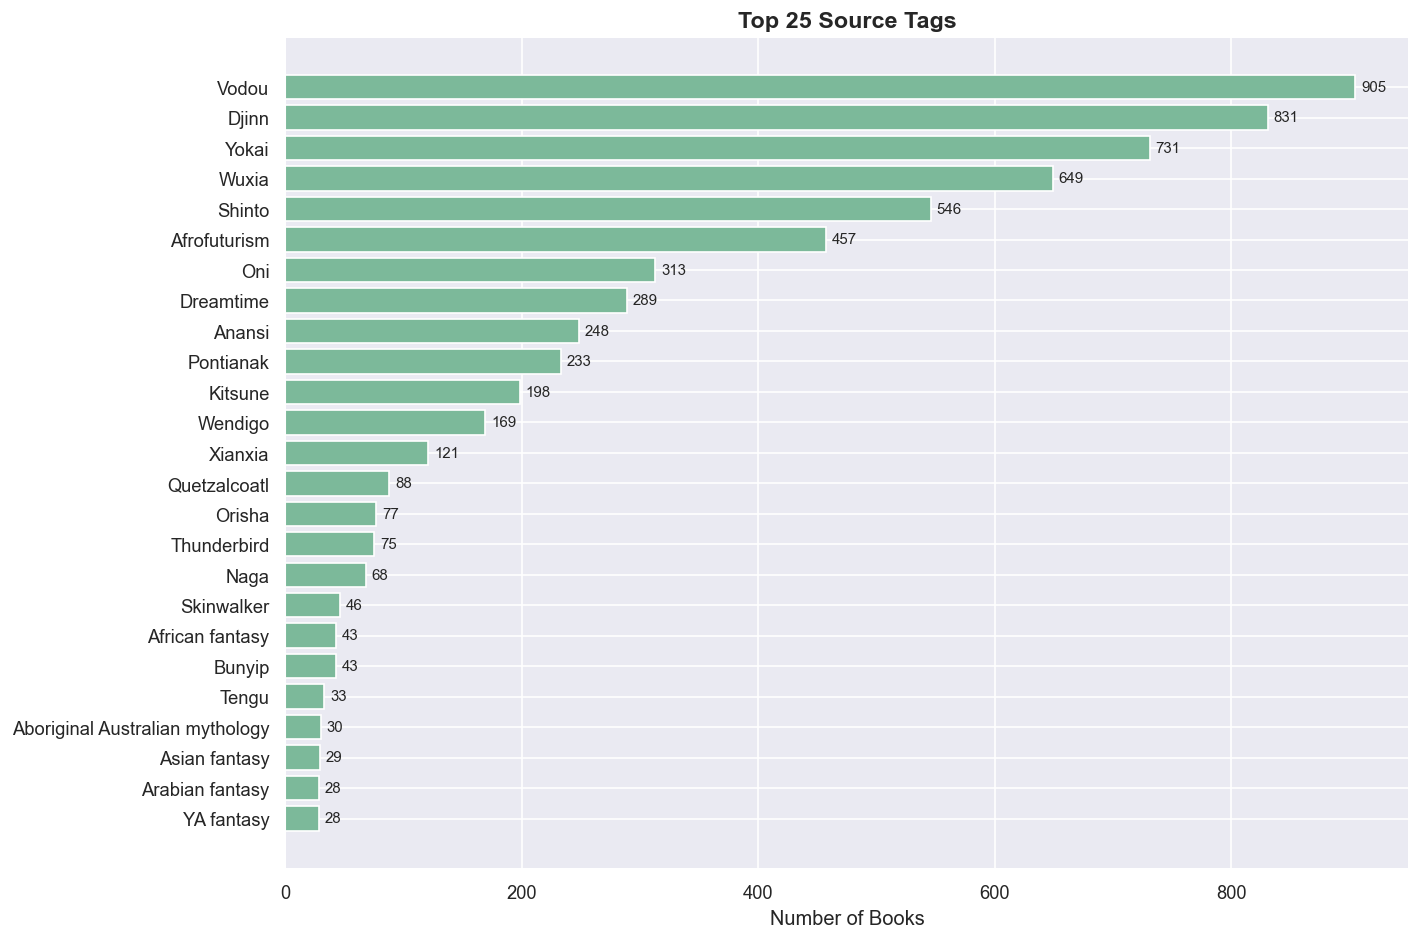

✅ Plot saved


In [14]:
# ── Plot 6: Top source tags ────────────────────────────────────────────────
tag_counts = df["source_tag"].value_counts().head(25)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(tag_counts.index[::-1], tag_counts.values[::-1], color="#7CB99A")
ax.set_title("Top 25 Source Tags", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Books")

for bar, val in zip(bars, tag_counts.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / "06_top_tags.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved")

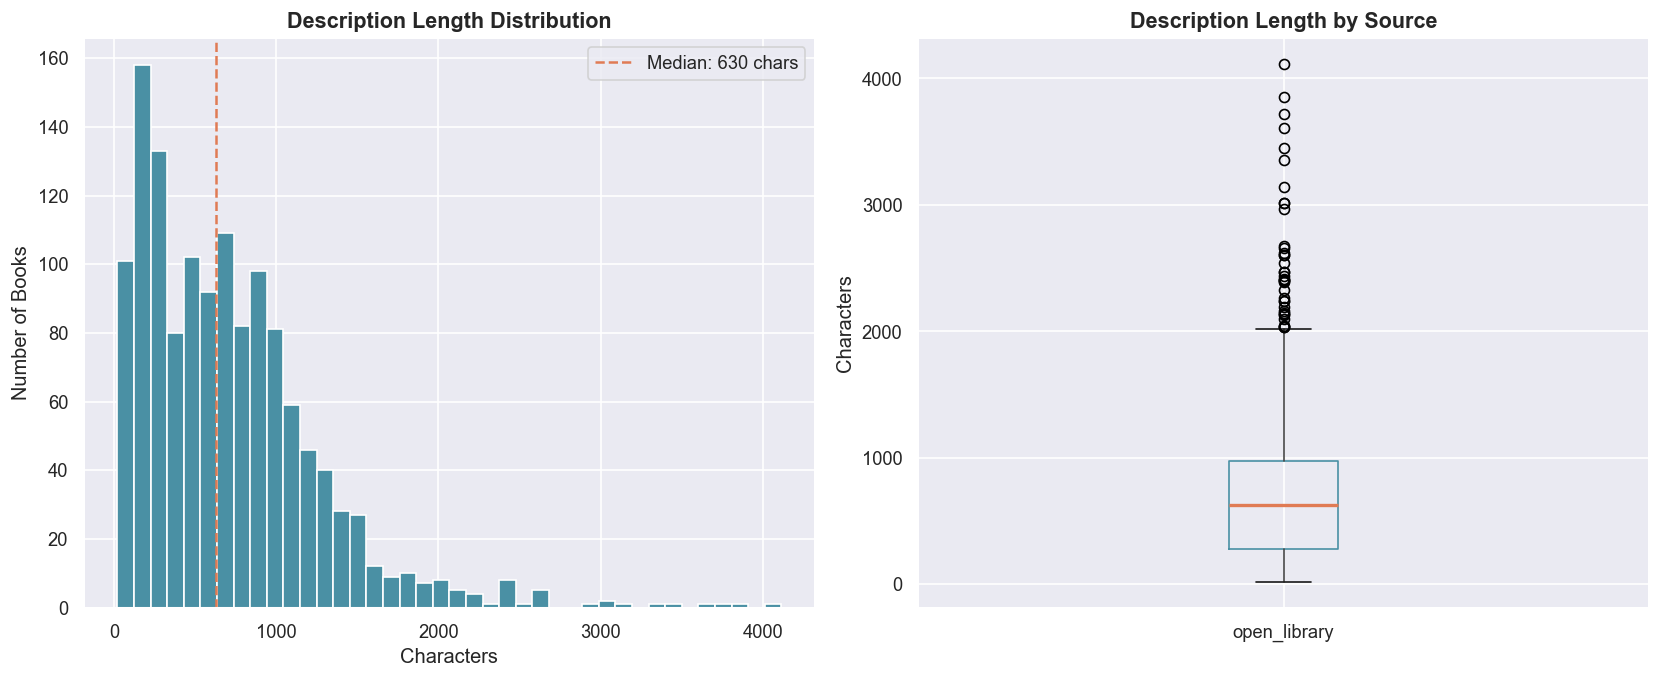

✅ Plot saved


In [15]:
# ── Plot 7: Description length distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

desc_lengths = df[df["has_description"]]["desc_length"]

axes[0].hist(desc_lengths, bins=40, color="#4A90A4", edgecolor="white")
axes[0].set_title("Description Length Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Number of Books")
axes[0].axvline(x=desc_lengths.median(), color="#E07B54", linestyle="--",
                linewidth=1.5, label=f"Median: {desc_lengths.median():.0f} chars")
axes[0].legend()

# Box plot by source
desc_df = df[df["has_description"]][["source", "desc_length"]]
desc_df.boxplot(column="desc_length", by="source", ax=axes[1],
                boxprops=dict(color="#4A90A4"),
                medianprops=dict(color="#E07B54", linewidth=2))
axes[1].set_title("Description Length by Source", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Characters")
plt.suptitle("")

plt.tight_layout()
plt.savefig(EDA_DIR / "07_description_lengths.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved")